# Propuesta 2: Convolución Cuántica (2 Qubits, Ventana 2x2)

Este notebook presenta la implementación final de la **Propuesta 2**, la cual utiliza una capa de convolución cuántica (downsampling) basada en **Amplitude Encoding** con 2 qubits y una ventana deslizante de 2x2 (stride 2).

Se evalúan tres escenarios de validación:
1. **Escenario 1 (Original)**: Dataset desbalanceado (.mat) con Hold-out simple.
2. **Escenario 2 (Estándar)**: Dataset balanceado (.npz), partición por paciente 70/15/15.
3. **Escenario 3 (5-Fold CV)**: Dataset balanceado (.npz), validación cruzada de 5 pliegues por paciente.

Todos los procesos incluyen medición detallada de tiempos y reportes estadísticos profesionales.

In [1]:
import os
import sys
import time
import h5py
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split, GroupShuffleSplit, GroupKFold
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# Importar el Motor Cuántico local
from quantum_utils import QuantumDownsampler

# Configuración de dispositivo
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.backends.mps.is_available():
    device = torch.device("mps")
print(f"Usando dispositivo: {device}")

# Mapeo de etiquetas
LABEL_MAP = {1: 0, 2: 1, 3: 2} # Meningioma, Glioma, Pituitario
CLASS_NAMES = ['Meningioma', 'Glioma', 'Pituitario']

Usando dispositivo: mps


In [2]:
class RedNeuronalGeneral(nn.Module):
    """
    Arquitectura MLP para clasificación de tumores.
    Para Propuesta 2, la entrada es (1, 64, 64) tras el downsampling.
    """
    def __init__(self, input_shape=(1, 64, 64), num_classes=3):
        super(RedNeuronalGeneral, self).__init__()
        self.input_dim = np.prod(input_shape)
        self.flatten = nn.Flatten()
        self.layers = nn.Sequential(
            nn.Linear(self.input_dim, 256),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(0.1), 
            nn.Dropout(0.3), 
            nn.Linear(256, 128), 
            nn.BatchNorm1d(128), 
            nn.LeakyReLU(0.1), 
            nn.Dropout(0.2), 
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.layers(x)
        return logits

In [3]:
def _resize_image(image, target_size=128):
    """Redimensiona una imagen 2D al tamaño objetivo y devuelve float32."""
    image = np.asarray(image, dtype=np.float32)
    if image.shape[:2] == (target_size, target_size):
        return image
    image_tensor = torch.from_numpy(image).unsqueeze(0).unsqueeze(0)
    resized = torch.nn.functional.interpolate(
        image_tensor,
        size=(target_size, target_size),
        mode='bilinear',
        align_corners=False,
    )
    return resized.squeeze(0).squeeze(0).cpu().numpy()


def load_original_data(dataset_path):
    """Carga el dataset original desbalanceado (.mat) y normaliza tamaños a 128x128."""
    X, y = [], []
    start_time = time.time()
    files = [f for f in os.listdir(dataset_path) if f.endswith('.mat')]
    print(f"Cargando {len(files)} archivos .mat...")
    
    for filename in tqdm(files):
        filepath = os.path.join(dataset_path, filename)
        with h5py.File(filepath, 'r') as f:
            data = f['cjdata']
            image = np.array(data['image'])
            label = int(data['label'][0,0])
            X.append(_resize_image(image))
            y.append(LABEL_MAP[label])
            
    elapsed = time.time() - start_time
    print(f"Carga completada en {elapsed:.2f}s")
    return np.stack(X, axis=0), np.array(y)


def load_balanced_data_npz(dataset_path):
    """Carga el dataset balanceado agrupado por pacientes (.npz) y asegura tamaño homogéneo."""
    X, y, groups = [], [], []
    start_time = time.time()
    
    classes = ['Meningioma', 'Glioma', 'Adenoma_hipofisario']
    for class_name in classes:
        class_dir = os.path.join(dataset_path, class_name)
        files = [f for f in os.listdir(class_dir) if f.endswith('.npz')]
        label = 0 if class_name == 'Meningioma' else (1 if class_name == 'Glioma' else 2)
        
        for filename in tqdm(files, desc=f"Cargando {class_name}"):
            filepath = os.path.join(class_dir, filename)
            patient_id = filename.replace('.npz', '')
            with np.load(filepath) as data:
                imgs = data['imagenes']
                for img in imgs:
                    X.append(_resize_image(img))
                    y.append(label)
                    groups.append(patient_id)
                    
    elapsed = time.time() - start_time
    print(f"Carga completada en {elapsed:.2f}s")
    return np.stack(X, axis=0), np.array(y), np.array(groups)

## Escenario 1: Dataset Original (Desbalanceado)

Cargando 3064 archivos .mat...


Cargando 3064 archivos .mat...


100%|██████████| 3064/3064 [00:10<00:00, 296.79it/s]


Cargando 3064 archivos .mat...


100%|██████████| 3064/3064 [00:10<00:00, 296.79it/s]


...

Cargando 3064 archivos .mat...


100%|██████████| 3064/3064 [00:10<00:00, 296.79it/s]


Carga completada en 10.34s
Aplicando Convolución Cuántica (Escenario 1)...


  0%|          | 0/3064 [00:00<?, ?it/s]

Generando diagrama del circuito cuántico...


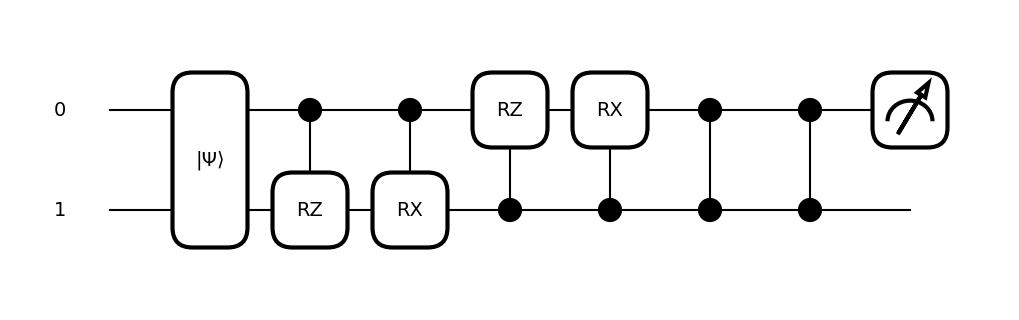

Cargando 3064 archivos .mat...


100%|██████████| 3064/3064 [00:10<00:00, 296.79it/s]


Carga completada en 10.34s
Aplicando Convolución Cuántica (Escenario 1)...


  0%|          | 0/3064 [00:00<?, ?it/s]

Generando diagrama del circuito cuántico...


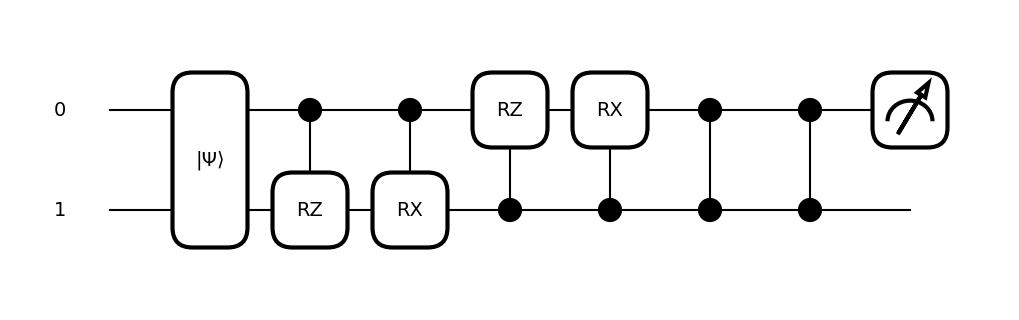

100%|██████████| 3064/3064 [00:12<00:00, 250.19it/s]


Cargando 3064 archivos .mat...


100%|██████████| 3064/3064 [00:10<00:00, 296.79it/s]


Carga completada en 10.34s
Aplicando Convolución Cuántica (Escenario 1)...


  0%|          | 0/3064 [00:00<?, ?it/s]

Generando diagrama del circuito cuántico...


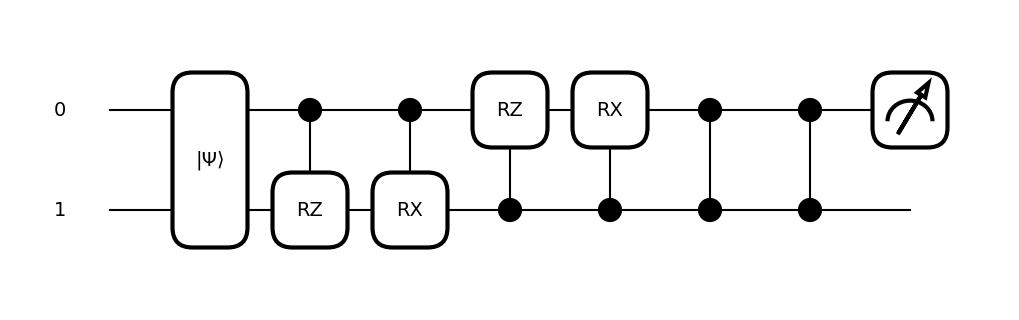

100%|██████████| 3064/3064 [00:12<00:00, 250.19it/s]


Tiempo total de procesamiento cuántico: 12.25s
Tiempo promedio por imagen: 3.9974ms

Distribución del Dataset - Train: 80.0% (2451), Test: 20.0% (613)

Iniciando entrenamiento (Escenario 1)...


Cargando 3064 archivos .mat...


100%|██████████| 3064/3064 [00:10<00:00, 296.79it/s]


Carga completada en 10.34s
Aplicando Convolución Cuántica (Escenario 1)...


  0%|          | 0/3064 [00:00<?, ?it/s]

Generando diagrama del circuito cuántico...


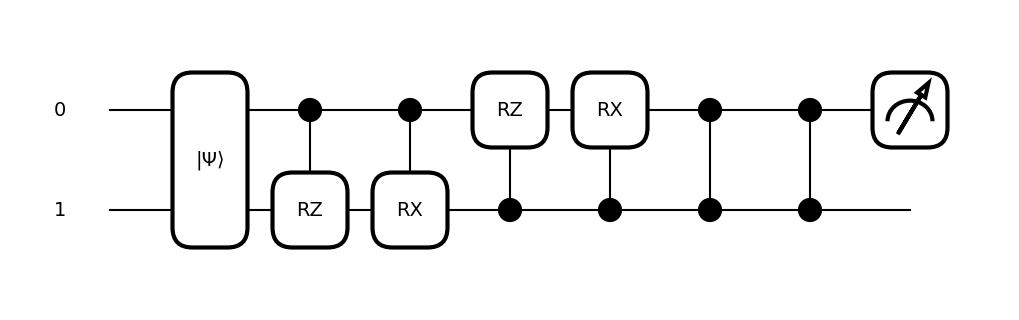

100%|██████████| 3064/3064 [00:12<00:00, 250.19it/s]


Tiempo total de procesamiento cuántico: 12.25s
Tiempo promedio por imagen: 3.9974ms

Distribución del Dataset - Train: 80.0% (2451), Test: 20.0% (613)

Iniciando entrenamiento (Escenario 1)...


Training: 100%|██████████| 50/50 [00:16<00:00,  2.99it/s]


Cargando 3064 archivos .mat...


100%|██████████| 3064/3064 [00:10<00:00, 296.79it/s]


Carga completada en 10.34s
Aplicando Convolución Cuántica (Escenario 1)...


  0%|          | 0/3064 [00:00<?, ?it/s]

Generando diagrama del circuito cuántico...


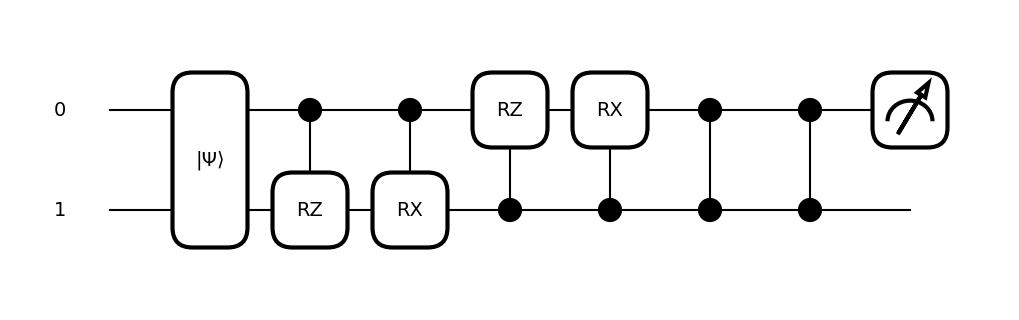

100%|██████████| 3064/3064 [00:12<00:00, 250.19it/s]


Tiempo total de procesamiento cuántico: 12.25s
Tiempo promedio por imagen: 3.9974ms

Distribución del Dataset - Train: 80.0% (2451), Test: 20.0% (613)

Iniciando entrenamiento (Escenario 1)...


Training: 100%|██████████| 50/50 [00:16<00:00,  2.99it/s]


Entrenamiento completado en 16.70s

--- RESULTADOS ESCENARIO 1 ---
Accuracy: 88.09%
F1-Score (Macro): 87.47%

Reporte de Clasificación:
              precision    recall  f1-score   support

  Meningioma       0.82      0.75      0.78       171
      Glioma       0.89      0.90      0.90       262
  Pituitario       0.92      0.97      0.94       180

    accuracy                           0.88       613
   macro avg       0.88      0.88      0.87       613
weighted avg       0.88      0.88      0.88       613



In [4]:
MAT_PATH = '../../DataSet/Tumores'
X_orig, y_orig = load_original_data(MAT_PATH)

q_sampler = QuantumDownsampler(n_qubits=2)
X_quantum_orig = []

print("Aplicando Convolución Cuántica (Escenario 1)...")
start_q = time.time()
for img in tqdm(X_orig):
    X_quantum_orig.append(q_sampler.process_image(img))
time_q = time.time() - start_q

X_quantum_orig = np.array(X_quantum_orig)
print(f"Tiempo total de procesamiento cuántico: {time_q:.2f}s")
print(f"Tiempo promedio por imagen: {(time_q/len(X_orig))*1000:.4f}ms")

# Split 80/20
X_train, X_test, y_train, y_test = train_test_split(X_quantum_orig, y_orig, test_size=0.2, random_state=42)

p_train = (len(X_train)/len(X_orig))*100
p_test = (len(X_test)/len(X_orig))*100
print(f"\nDistribución del Dataset - Train: {p_train:.1f}% ({len(X_train)}), Test: {p_test:.1f}% ({len(X_test)})")

train_ds = TensorDataset(torch.tensor(X_train, dtype=torch.float32).unsqueeze(1), torch.tensor(y_train, dtype=torch.long))
test_ds = TensorDataset(torch.tensor(X_test, dtype=torch.float32).unsqueeze(1), torch.tensor(y_test, dtype=torch.long))
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, drop_last=True)
test_loader = DataLoader(test_ds, batch_size=32)

model = RedNeuronalGeneral(input_shape=(1, 64, 64)).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("\nIniciando entrenamiento (Escenario 1)...")
start_t = time.time()
for epoch in tqdm(range(50), desc="Training"):
    model.train()
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

time_t = time.time() - start_t
print(f"Entrenamiento completado en {time_t:.2f}s")

# Evaluación Final
model.eval()
preds = []
with torch.no_grad():
    for inputs, labels in test_loader:
        outputs = model(inputs.to(device))
        preds.extend(torch.max(outputs, 1)[1].cpu().numpy())

print(f"\n--- RESULTADOS ESCENARIO 1 ---")
print(f"Accuracy: {accuracy_score(y_test, preds)*100:.2f}%")
print(f"F1-Score (Macro): {f1_score(y_test, preds, average='macro')*100:.2f}%")
print("\nReporte de Clasificación:")
print(classification_report(y_test, preds, target_names=CLASS_NAMES))

## Escenario 2: Dataset Balanceado (Hold-out 70/15/15 por Paciente)

In [5]:
BALANCED_PATH = '../../Codigo/Dataset_Balanceado_700'
X_bal, y_bal, groups_bal = load_balanced_data_npz(BALANCED_PATH)

X_quantum_bal = []
print("Aplicando Convolución Cuántica (Escenario 2)...")
start_q = time.time()
for img in tqdm(X_bal):
    X_quantum_bal.append(q_sampler.process_image(img))
time_q = time.time() - start_q
X_quantum_bal = np.array(X_quantum_bal)
print(f"Procesamiento cuántico: {time_q:.2f}s ({(time_q/len(X_bal))*1000:.4f} ms/img)")

# Split 70/15/15 por paciente
gss = GroupShuffleSplit(n_splits=1, train_size=0.7, random_state=42)
train_idx, val_test_idx = next(gss.split(X_quantum_bal, y_bal, groups_bal))

X_temp, y_temp, groups_temp = X_quantum_bal[val_test_idx], y_bal[val_test_idx], groups_bal[val_test_idx]
gss_val = GroupShuffleSplit(n_splits=1, train_size=0.5, random_state=42)
val_idx, test_idx = next(gss_val.split(X_temp, y_temp, groups_temp))

X_train, y_train = X_quantum_bal[train_idx], y_bal[train_idx]
X_val, y_val = X_temp[val_idx], y_temp[val_idx]
X_test, y_test = X_temp[test_idx], y_temp[test_idx]

total = len(y_bal)
print(f"\nDistribución: Train: {len(y_train)/total*100:.1f}% ({len(y_train)}), Val: {len(y_val)/total*100:.1f}% ({len(y_val)}), Test: {len(y_test)/total*100:.1f}% ({len(y_test)})")

train_loader = DataLoader(TensorDataset(torch.tensor(X_train, dtype=torch.float32).unsqueeze(1), torch.tensor(y_train, dtype=torch.long)), batch_size=32, shuffle=True, drop_last=True)
val_loader = DataLoader(TensorDataset(torch.tensor(X_val, dtype=torch.float32).unsqueeze(1), torch.tensor(y_val, dtype=torch.long)), batch_size=32)
test_loader = DataLoader(TensorDataset(torch.tensor(X_test, dtype=torch.float32).unsqueeze(1), torch.tensor(y_test, dtype=torch.long)), batch_size=32)

model = RedNeuronalGeneral().to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

best_acc = 0
start_t = time.time()
for epoch in tqdm(range(50), desc="Training Standard"):
    model.train()
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
    
    model.eval()
    preds = []
    with torch.no_grad():
        for inputs, labels in val_loader:
            outputs = model(inputs.to(device))
            preds.extend(torch.max(outputs, 1)[1].cpu().numpy())
    acc = accuracy_score(y_val, preds)
    if acc > best_acc:
        best_acc = acc
        torch.save(model.state_dict(), "best_p2_standard.pth")

total_t = time.time() - start_t
print(f"Entrenamiento (Hold-out) completado en {total_t:.2f}s")

# Evaluación en Test
model.load_state_dict(torch.load("best_p2_standard.pth"))
model.eval()
preds = []
with torch.no_grad():
    for inputs, labels in test_loader:
        outputs = model(inputs.to(device))
        preds.extend(torch.max(outputs, 1)[1].cpu().numpy())

print(f"\n--- RESULTADOS ESCENARIO 2 ---")
print(f"Accuracy en Test: {accuracy_score(y_test, preds)*100:.2f}%")
print(f"F1-Score en Test: {f1_score(y_test, preds, average='macro')*100:.2f}%")

Cargando Adenoma_hipofisario: 100%|██████████| 62/62 [00:00<00:00, 361.61it/s]


Cargando Adenoma_hipofisario: 100%|██████████| 62/62 [00:00<00:00, 361.61it/s]


Carga completada en 0.55s
Aplicando Convolución Cuántica (Escenario 2)...


100%|██████████| 2098/2098 [00:06<00:00, 302.72it/s]


Cargando Adenoma_hipofisario: 100%|██████████| 62/62 [00:00<00:00, 361.61it/s]


...

Carga completada en 0.55s
Aplicando Convolución Cuántica (Escenario 2)...


100%|██████████| 2098/2098 [00:06<00:00, 302.72it/s]


Procesamiento cuántico: 6.93s (3.3040 ms/img)

Distribución: Train: 70.9% (1488), Val: 14.5% (305), Test: 14.5% (305)


Training Standard: 100%|██████████| 50/50 [00:09<00:00,  5.20it/s]


Entrenamiento (Hold-out) completado en 9.62s

--- RESULTADOS ESCENARIO 2 ---
Accuracy en Test: 80.33%
F1-Score en Test: 79.80%


## Escenario 3: Dataset Balanceado (5-Fold CV por Paciente)

In [6]:
gkf = GroupKFold(n_splits=5)
fold_accs = []
fold_f1s = []
fold_test_scores = []
fold_test_f1s = []

print(f"Iniciando 5-Fold Cross Validation por Paciente...")
start_cv = time.time()

for fold, (train_idx, test_idx) in enumerate(gkf.split(X_quantum_bal, y_bal, groups_bal)):
    X_train_fold, y_train_fold = X_quantum_bal[train_idx], y_bal[train_idx]
    X_test_fold, y_test_fold = X_quantum_bal[test_idx], y_bal[test_idx]
    
    train_loader = DataLoader(TensorDataset(torch.tensor(X_train_fold, dtype=torch.float32).unsqueeze(1), torch.tensor(y_train_fold, dtype=torch.long)), batch_size=32, shuffle=True, drop_last=True)
    test_loader = DataLoader(TensorDataset(torch.tensor(X_test_fold, dtype=torch.float32).unsqueeze(1), torch.tensor(y_test_fold, dtype=torch.long)), batch_size=32)
    
    model = RedNeuronalGeneral().to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()
    
    for epoch in range(50):
        model.train()
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
    model.eval()
    preds = []
    with torch.no_grad():
        for inputs, labels in test_loader:
            outputs = model(inputs.to(device))
            preds.extend(torch.max(outputs, 1)[1].cpu().numpy())
            
    fold_acc = accuracy_score(y_test_fold, preds)
    fold_f1 = f1_score(y_test_fold, preds, average='macro')
    fold_accs.append(fold_acc)
    fold_f1s.append(fold_f1)
    fold_test_scores.append(fold_acc)
    fold_test_f1s.append(fold_f1)
    print(f"Fold {fold+1} completado. Acc: {fold_acc*100:.2f}%, F1: {fold_f1*100:.2f}%")

    
total_cv_time = time.time() - start_cv
print(f"\n--- RESULTADOS ESCENARIO 3 (5-FOLD CV) ---")
print(f"Accuracy Promedio: {np.mean(fold_accs)*100:.2f}% ± {np.std(fold_accs)*100:.2f}%")
print(f"F1-Score Promedio: {np.mean(fold_f1s)*100:.2f}% ± {np.std(fold_f1s)*100:.2f}%")
print(f"Test Score Promedio: {np.mean(fold_test_scores)*100:.2f}% ± {np.std(fold_test_scores)*100:.2f}%")
print(f"Test F1-Score Promedio: {np.mean(fold_test_f1s)*100:.2f}% ± {np.std(fold_test_f1s)*100:.2f}%")
print(f"Tiempo total CV: {total_cv_time:.2f}s")

Iniciando 5-Fold Cross Validation por Paciente...
Fold 1 completado. Acc: 80.00%, F1: 79.83%
Fold 2 completado. Acc: 82.62%, F1: 79.43%
Fold 3 completado. Acc: 86.67%, F1: 86.74%
Fold 4 completado. Acc: 83.29%, F1: 83.38%
Fold 5 completado. Acc: 85.68%, F1: 85.13%

--- RESULTADOS ESCENARIO 3 (5-FOLD CV) ---
Accuracy Promedio: 83.65% ± 2.36%
F1-Score Promedio: 82.90% ± 2.88%
Test Score Promedio: 83.65% ± 2.36%
Test F1-Score Promedio: 82.90% ± 2.88%
Tiempo total CV: 49.07s
